# SWIGGY SALES ANALYSIS

### Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import plotly.express as px

### Importing the sales data to python

In [13]:
df = pd.read_excel("excel file/swiggy_data.xlsx")

In [15]:
df.head(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,2025-04-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


### Metadata


In [19]:
print("Number of rows in the dataset are", df.shape[0])

Number of rows in the dataset are 197430


In [21]:
print("Number of fields/columns in the dataset are", df.shape[1])

Number of fields/columns in the dataset are 10


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  str           
 1   City             197430 non-null  str           
 2   Order Date       197430 non-null  datetime64[us]
 3   Restaurant Name  197430 non-null  str           
 4   Location         197430 non-null  str           
 5   Category         197430 non-null  str           
 6   Dish Name        197430 non-null  str           
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 15.1 MB


In [26]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


## KPIs

### Total Sales

In [29]:
total_sales = df["Price (INR)"].sum()
print("Total sales: ", round(total_sales,2))

Total sales:  53012505.77


### Average Rating

In [31]:
avg_rating = df["Rating"].mean()
print("Average Rating: ", round(avg_rating,2))

Average Rating:  4.34


### Average Order Value

In [32]:
avg_oder_value = df["Price (INR)"].mean()
print("Average Order Value: ", round(avg_oder_value,2))

Average Order Value:  268.51


### Total Rating Count

In [33]:
rating_count = df["Rating Count"].sum()
print("Total Rating Count: ", round(rating_count,2))

Total Rating Count:  5591574


### Total Orders

In [37]:
total_orders= len(df)
print("Total No. of Orders: ", total_orders)


Total No. of Orders:  197430


## CHARTS

### Monthly Sales Trend

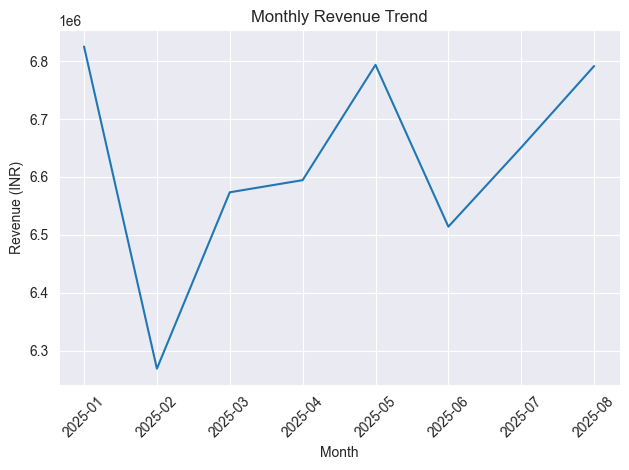

In [39]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue=df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

### Daily Sales Trend

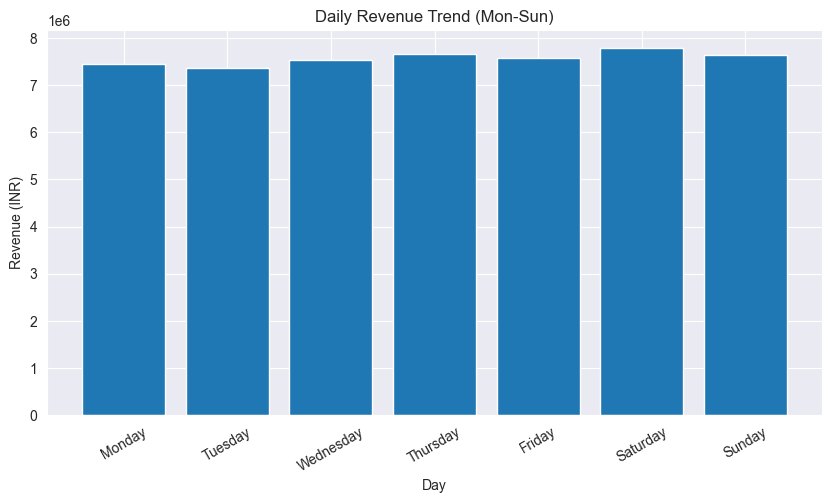

In [41]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
    df.groupby("DayName")["Price (INR)"]
    .sum()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()

### Total Sales by Food Type (Veg v/s Non-Veg)

In [42]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kabab", "kebab",
    "non-veg", "non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)
food_revenue = (
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

### Total Sales by State

In [43]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
      .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)"
)

fig.update_layout(
    height=600,
    yaxis=dict(autorange="reversed")
)

fig.show()

### Quarterly Performance Summary

In [47]:
import pandas as pd

# I changed "Order_Date" to "Order Date" (with a space)
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order Date", "count")  # Updated here too
    )
    .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Top 5 cities by Sales

In [48]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()

### Weekly Sales Trend Analysis

In [49]:
# 1. Ensure date is converted (if not already done)
df["Order Date"] = pd.to_datetime(df["Order Date"])

# 2. Create the Weekly Summary
weekly_summary = (
    df.groupby(df["Order Date"].dt.to_period("W"))["Price (INR)"]
    .sum()
    .reset_index()
)

# Convert period to string so Plotly can read it easily
weekly_summary["Order Date"] = weekly_summary["Order Date"].astype(str)

# 3. Create the Line Chart
fig_weekly = px.line(
    weekly_summary,
    x="Order Date",
    y="Price (INR)",
    title="Weekly Sales Trend Analysis",
    markers=True,
    line_shape="spline", # This makes the line smooth/curvy
    color_discrete_sequence=["red"]
)

fig_weekly.show()